[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maxischa/datacamp_test/blob/main/bloc4_ml/cours/seance1_cours.ipynb)

# Séance 4.1 — Le Machine Learning : prédire n'est pas expliquer

**Cours** · durée : 2h (≈50 min de cours, ≈50 min d'exercices)

> ⚠️ **Avant de taper quoi que ce soit :** *Fichier → Enregistrer une copie dans Drive*. Sinon votre travail sera perdu en fermant l'onglet.
>
> 📱 Sur tablette, faites d'abord les réglages de [Bien démarrer](https://github.com/maxischa/datacamp_test/blob/main/ressources/setup_tablette.md).

## Objectifs

À la fin de cette séance, vous saurez :

- dire ce qui sépare un modèle qui explique d'un modèle qui prédit
- découper un jeu de données en apprentissage et test, et dire pourquoi
- mesurer une erreur de prédiction en euros avec la RMSE et la MAE
- reconnaître un surapprentissage à l'écart entre les deux jeux
- repérer une fuite de données — l'erreur qui donne un modèle parfait et inutile

## Plan de la séance

1. **Comprendre l'apprentissage automatique et ses grandes familles**
   - 1.1 Un premier exemple : la détection des courriels indésirables
   - 1.2 L'apprentissage supervisé
     - 1.2.1 La classification
     - 1.2.2 La régression
   - 1.3 L'apprentissage non supervisé
     - 1.3.1 Le clustering
     - 1.3.2 L'association
   - 1.4 L'apprentissage par renforcement
2. **Illustrer le machine learning avec une régression linéaire**
   - **2.1 Porter un regard prédictif sur un modèle descriptif**
     - 2.1.1 Définir les variables `X` et `y`
     - 2.1.2 Visualiser la relation entre les variables
     - 2.1.3 Ajuster et interpréter la droite OLS
     - 2.1.4 Mesurer l'ajustement sur les données observées
   - **2.2 Pas encore prédictif**
     - 2.2.1 Comprendre la limite du premier ajustement
     - 2.2.2 Introduire les jeux d'apprentissage et de test
3. **Passer de la description à la prédiction**
   - **3.1 Entraîner et prédire**
     - 3.1.1 Constituer les jeux d'apprentissage et de test
     - 3.1.2 Entraîner le modèle
     - 3.1.3 Produire les prédictions
   - **3.2 Évaluer le modèle**
     - 3.2.1 Calculer la MAE
     - 3.2.2 Calculer la RMSE
     - 3.2.3 Calculer le R²
     - 3.2.4 Comparer apprentissage et test
4. **Reconnaître deux erreurs d'évaluation**
   - 4.1 L'erreur bruyante : mélanger les jeux
   - 4.2 L'erreur silencieuse : la fuite de données
5. **Synthèse**
   - 5.1 Aide-mémoire des commandes
   - 5.2 Les quatre phrases à retenir

## 1. Comprendre l'apprentissage automatique et ses grandes familles

Le machine learning (apprentissage automatique) est un sous-ensemble de
l'intelligence artificielle (IA). Le principe est de créer un modèle
statistique qui apprend à partir des données **d'entraînement** et améliore sa
précision au fil du temps sur les données dites de **test**. Ces algorithmes
permettent, par la prévision, d'éclairer les décisions.

En ce sens, le machine learning n'est pas fondamentalement différent d'un
modèle statistique classique. Ce qui change, ce sont les notions
d'entraînement, de test et de **prédiction**. À partir d'un modèle de
description d'un état des données, nous essayons de prédire le comportement
des données dans un autre état.

### 1.1 Un premier exemple : la détection des courriels indésirables

Comprenons cela à l'aide d'un exemple simple. Supposons que nous ayons un
ensemble de données de 30 000 courriels dont certains sont classés comme spam
et d'autres comme non spam. Nous entraînons le modèle d'apprentissage
automatique sur cette base pour qu'il puisse prédire quel courriel est à
classer dans les spams et lequel ne l'est pas. Une fois le processus
d'apprentissage terminé, nous pouvons le tester avec un courriel qui n'était
pas inclus dans notre ensemble de données d'apprentissage. Il nous dira s'il
faut, ou non, le classer dans les spams.

Les méthodes de machine learning se répartissent en trois grandes familles :

### 1.2 L'apprentissage supervisé

Dans l'apprentissage supervisé, la machine sait déjà à quoi doit ressembler la
sortie correcte. Elle sait déjà qu'il existe une relation entre la variable
d'entrée et la variable de sortie. Il s'agit de la méthode d'entraînement du
modèle avec des jeux de données spécifiquement étiquetés (labélisés). Les jeux
de données peuvent être une classification binaire ou une classification
multi-classes. Ces ensembles de données auront des données étiquetées
spécifiant les options correctes et incorrectes ou une gamme d'options.

*Exemple : Vous disposez d'un ensemble de données sur les maisons avec leurs
caractéristiques telles que l'emplacement, les mètres carrés, les prix, etc. et
vous voulez déterminer le prix d'une maison que vous ne connaissez pas encore.
La machine va prédire le prix de la nouvelle maison en se basant sur son
apprentissage à partir de l'ensemble de données fourni.*

#### 1.2.1 La classification

La classification est le processus qui consiste à construire un modèle qui
sépare les données d'entrée en plusieurs classes discrètes ou étiquettes. Elle
prédit des valeurs discrètes telles que Vrai ou Faux, Homme ou Femme, Spam ou
Non, Chaud ou Froid, etc.

__Algorithmes de classification :__

    Régression logistique
    KNN pour la classification
    Machine à vecteur de support : SVC (Support Vector Classifier)
    Classification par arbre de décision
    Classification Random Forest
    Naive Bayes

#### 1.2.2 La régression

La régression est le processus qui consiste à construire un modèle qui prédit
une valeur continue sur la base de ses variables d'entrée. Elle permet de
prédire des valeurs continues telles que la température, le prix, le salaire,
l'âge, etc.

__Algorithmes de régression :__

    Régression linéaire simple
    Régression linéaire multiple
    Régression polynomiale
    KNN pour la régression
    Régression logistique
    Machine à vecteur de support : SVR (Régresseur à vecteur de support)
    Régression par arbre de décision
    Régression Random Forest

### 1.3 L'apprentissage non supervisé

Dans l'apprentissage non supervisé, la machine ne sait pas quelle est la sortie
correcte. Ces modèles nous permettent d'aborder les problèmes avec peu ou pas
d'idée de ce à quoi nos résultats devraient ressembler. Nous pouvons simplement
dériver la structure des données en les regroupant sur la base des relations
entre les variables de l'ensemble de données. Cela signifie que le modèle ne
reçoit aucune information préalable. Il s'entraîne lui-même en regroupant des
caractéristiques et des modèles similaires.

*Exemple : Une entreprise souhaite mieux comprendre le comportement de ses
clients, mais ne dispose d'aucune catégorie prédéfinie. Elle utilise alors un
algorithme de clustering, comme K-means, à partir de variables telles que la
fréquence d'achat et le montant moyen dépensé. L'algorithme regroupe
automatiquement les clients les plus similaires et peut, par exemple, faire
apparaître trois profils : les clients occasionnels qui dépensent peu, les
clients réguliers et les clients très fidèles qui dépensent beaucoup. Il s'agit
d'un apprentissage non supervisé, car l'algorithme découvre seul des groupes
dans les données, sans connaître à l'avance la catégorie de chaque client.*

#### 1.3.1 Le clustering

Le clustering est le processus qui consiste à regrouper des objets en clusters.
Les objets présentant le plus de similitudes se retrouvent dans un groupe, et
les objets présentant moins ou pas de similitudes dans un autre groupe. Pensez
à l'entraînement des modèles de computer vision. Le modèle ne comprend pas si
l'image est un chat ou non. Mais on lui a donné des millions d'images de chats,
et la similitude de la nouvelle photo de chat qu'on lui donne avec ces photos
permet le clustering en « chat » de cette nouvelle donnée.

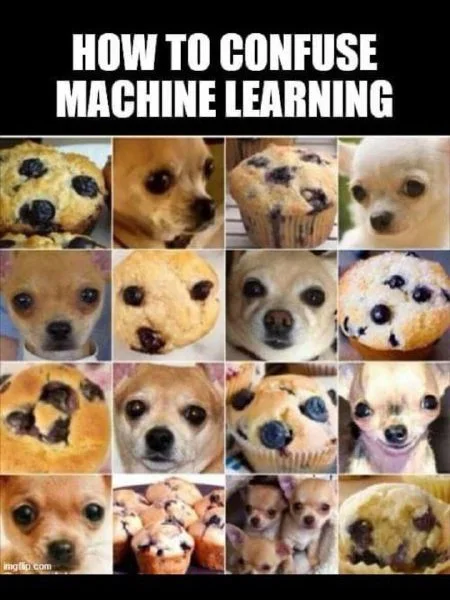

Algorithmes de clustering :

    K-Means Clustering
    Clustering K-Modes
    Clustering hiérarchique
    DBSCAN

#### 1.3.2 L'association

L'association est un processus qui est utilisé pour trouver des relations entre
les variables dans une grande base de données. Il est utilisé pour découvrir
l'ensemble des éléments qui se produisent ensemble dans l'ensemble de données.
Par exemple, les personnes qui achètent des articles A ont également tendance à
acheter des articles B.

### 1.4 L'apprentissage par renforcement

L'apprentissage par renforcement (RL) est un domaine de l'apprentissage
automatique qui s'intéresse à la manière dont les agents logiciels devraient
entreprendre des actions dans un environnement afin de maximiser la notion de
récompense cumulative.

L'apprentissage par renforcement est une sorte de modèle de méthode « hit and
try ». Il s'agit d'une méthode où le modèle apprend avec des échecs répétés.
Lorsqu'un modèle n'atteint pas le résultat souhaité, il se réentraîne. Cette
méthode peut être appliquée à des concepts tels que le jeu d'échecs, où, après
avoir joué des millions de parties, le modèle sera capable d'apprendre des
modèles et des mouvements appropriés. Un exemple plus simple serait un jeu de
tic tac toe. Le modèle peut apprendre tous les chemins de la victoire après
quelques centaines de parties et, une fois parfaitement entraîné, il ne perdra
jamais une partie.

#### 1.4.1 Principales approches

Algorithmes d'apprentissage par renforcement basés sur des politiques, des
valeurs et des modèles.

    Model-based VS model-free
    On-policy VS off-policy
    Bootstrap

Applications : apprentissage de modèles pour jouer à des jeux comme Flappy
Bird, robotique dans l'automatisation industrielle, contrôle du trafic,
apprentissage par renforcement basé sur l'apprentissage profond.

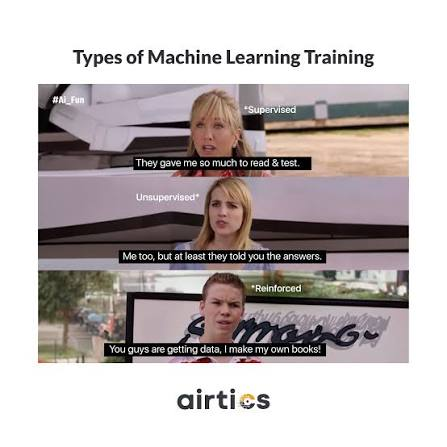

## 2. Illustrer le machine learning avec une régression linéaire

### 2.1 Porter un regard prédictif sur un modèle descriptif

La régression linéaire peut être utilisée comme outil descriptif mais aussi
comme outil prédictif. Il s'agit en fait ici d'utiliser la même équation, mais
pour répondre à une question différente.

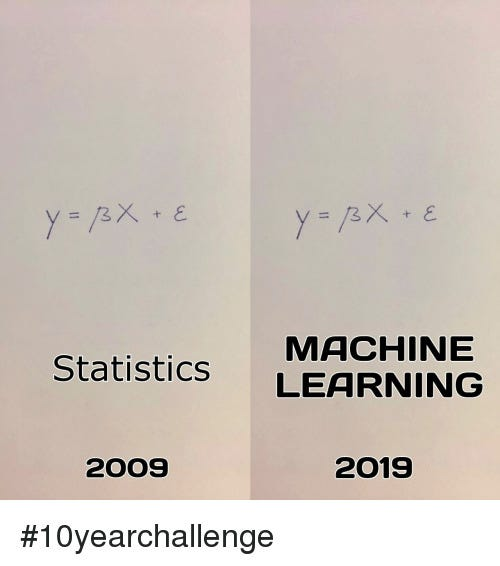

Pour rappel, la régression linéaire simple est une méthode qui permet de
modéliser la relation entre deux variables :

- **Variable indépendante (X)** : une caractéristique utilisée pour prédire.
- **Variable dépendante (Y)** : la valeur que nous cherchons à prédire.

L'objectif est de trouver une droite qui minimise la somme des erreurs entre
les valeurs observées $y_i$ et les valeurs prédites ($\hat{y}_i$).

C'est une technique fondamentale en apprentissage machine pour comprendre
comment une variable impacte directement une autre. Cette relation est une
relation **continue**.

En séance 3.4, nous avons ajusté `ca ~ qte` et lu le coefficient : **1,44 € par
article**. C'était de l'**explication**. On cherchait à comprendre les relations
qui existaient dans les données observées. Dans ce cours, la question est
différente. On passe de :

> Quel est le chiffre d'affaires observé par article, relativement à la
> quantité vendue par la commande enregistrée ?

à :

> *« Une commande arrive : 150 unités, 12 produits distincts. Combien va-t-elle
> rapporter ? »*

C'est de la **prédiction**, et plus de l'interprétation voire de l'explication.
La même équation peut servir aux deux. Ce qui change, et c'est tout le sujet
de la séance, c'est **la façon de la juger**.

Reprenons la même base de données pour illustrer la notion de prédiction en
utilisant un modèle OLS.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Affichage adapte aux petits ecrans
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 80)

# Les donnees sont lues directement depuis le web : rien a telecharger
BASE = "https://raw.githubusercontent.com/maxischa/datacamp_test/main/bloc4_ml/data/"

#### 2.1.1 Définir les variables `X` et `y`

C'est ainsi qu'intervient la notion d'apprentissage supervisé que nous
évoquions en introduction. Nous voulons construire un modèle statistique qui
nous fournit des prédictions sur une relation prédéfinie : celle entre la
quantité d'articles vendus et le chiffre d'affaires.

Définissons nos variables dépendante et indépendantes. La variable dépendante
représente la quantité que l'on cherche à prédire. Les variables indépendantes
correspondent aux quantités qui expliquent la prédiction donnée sur notre
variable d'intérêt. Elles déterminent le comportement derrière la prédiction.

In [ ]:
cmd = pd.read_csv(BASE + "commandes.csv")

X = cmd[["qte"]]      ## l'unique information connue avant de facturer
y = cmd["ca"]         ## ce que l'on veut prevoir

print(X.shape, y.shape)

#### 2.1.2 Visualiser la relation entre les variables

Comme précisé dans l'introduction du cours, pour choisir le modèle statistique
le plus approprié à la prédiction que l'on souhaite faire, mais aussi aux
données dont nous disposons, on commence par **visualiser**.

In [ ]:
# Visualisation
plt.figure(figsize=(7, 4))
plt.scatter(X["qte"], y, s=18, alpha=0.30, color="#2878B5")
plt.xlabel("Quantite commandee (qte)")
plt.ylabel("Chiffre d'affaires (ca, en euros)")
plt.title("Relation entre la quantite et le chiffre d'affaires")
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()

#### 2.1.3 Ajuster et interpréter la droite OLS

Après visualisation, on peut raisonnablement penser qu'un modèle de régression
linéaire est utile à une bonne prédiction à partir du comportement des données
actuelles.

On commence donc à construire le modèle qui servira à prédire le rapport entre
une nouvelle quantité vendue et le chiffre d'affaires.

In [ ]:
# Ajustement de la regression lineaire simple (OLS) : ca ~ qte
ols_visuel = LinearRegression().fit(X, y)

# Une grille triee permet de tracer une droite continue de gauche a droite
grille_qte = pd.DataFrame({"qte": np.linspace(X["qte"].min(), X["qte"].max(), 200)})
ca_predite = ols_visuel.predict(grille_qte)

plt.figure(figsize=(7, 4))
plt.scatter(X["qte"], y, s=18, alpha=0.25, color="#2878B5", label="Commandes observees")
plt.plot(grille_qte["qte"], ca_predite, color="#D64541", linewidth=3, label="Droite OLS")
plt.xlabel("Quantite commandee (qte)")
plt.ylabel("Chiffre d'affaires (ca, en euros)")
plt.title("Regression lineaire simple : ca ~ qte")
plt.grid(alpha=0.20)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Lecture explicite des parametres estimes par l'OLS
constante = ols_visuel.intercept_
coefficient_qte = ols_visuel.coef_[0]
r2_ols = ols_visuel.score(X, y)

print(f"Constante : {constante:.2f} euros")
print(f"Coefficient de qte : {coefficient_qte:.2f} euros par article")
print(f"Equation estimee : ca = {constante:.2f} + {coefficient_qte:.2f} x qte")
print()
print("Interpretation :")
print(f"- Une unite supplementaire commandee est associee a une hausse moyenne "
      f"de {coefficient_qte:.2f} euros du chiffre d'affaires predit.")
print(f"- Pour qte = 0, le modele predit {constante:.2f} euros. La constante "
      "positionne la droite et n'a pas necessairement de sens economique.")
print(f"- R2 = {r2_ols:.3f} : la quantite explique environ {r2_ols * 100:.1f} % "
      "de la variabilite observee du chiffre d'affaires.")
print("- Cette relation est une association statistique, pas un effet causal.")

#### 2.1.4 Mesurer l'ajustement sur les données observées

Comme pour une régression linéaire qu'on lirait de façon descriptive, on peut
s'assurer du « fit » de notre droite avec le R².

In [ ]:
print(f"R2 : {ols_visuel.score(X, y):.3f}")

### 2.2 Pas encore prédictif

#### 2.2.1 Comprendre la limite du premier ajustement

Notre modèle explique 71,9 % des variations observées dans notre base de
données entre la variable quantité et le chiffre d'affaires réalisé. C'est un
des indicateurs importants de la qualité de notre modèle pour prédire le
chiffre d'affaires que nous rapportera X quantité additionnelle vendue.

La limite de cet indicateur est que cette note a été calculée **sur les
données qui ont servi à construire le modèle**. Il ne s'agit pas d'une
évaluation d'un modèle prédictif, mais descriptif.

En d'autres termes, c'est réviser sur l'annale, puis passer cette annale comme
examen. Le résultat ne dit rien de ce qui se passera lors du véritable examen.

> **La règle du bloc :** un modèle se juge sur des données qu'il n'a jamais
> vues. Sinon, on ne mesure pas sa capacité à prédire, on mesure sa capacité à
> retenir.

Heureusement, il ne s'agit pas du seul indicateur dont nous disposons. Il
existe d'autres indicateurs qui expliquent d'autres aspects de la qualité de
notre modèle, en particulier son aspect prédictif.

Mais avant de les introduire, il nous faut introduire une notion centrale du
machine learning : les données d'apprentissage et les données de test.
Jusqu'ici nous avons seulement lu le modèle d'OLS de façon descriptive, sans
jamais en faire un modèle **d'apprentissage** à proprement parler.

#### 2.2.2 Introduire les jeux d'apprentissage et de test

On a différencié les notions d'explication et d'interprétation de la notion de
prédiction. Ici, les deux reposent sur des modèles statistiques de régression
linéaire, mais ce que ces modèles expliquent, et a fortiori la manière de les
interpréter, est différent. Or, pour réaliser une prédiction, le modèle
statistique a besoin d'une chose essentielle : des **données d'entraînement**.

Comment fournir des données d'entraînement au modèle ? Pour cela on part de la
base de données initiale et on choisit volontairement de mettre de côté un
quart des lignes. Ainsi, le modèle ne les verra jamais pendant son
apprentissage.

C'est à partir de ces données dites d'entraînement que le modèle va établir des
prédictions. En d'autres termes, nous allons entraîner le modèle à comprendre
puis prédire les relations entre nos variables explicatives et nos variables
d'intérêt grâce aux données d'entraînement.

Une question subsiste : comment teste-t-on la qualité de la prédiction donnée
par le modèle ?

C'est à ce moment que nous introduisons une deuxième notion essentielle au
machine learning : **les données de test**. C'est en confrontant le produit des
prédictions du modèle à ces données que nous évaluerons la qualité de ses
prédictions.

## 3. Passer de la description à la prédiction

Concrètement donc, pour passer de la description à la prédiction, nous allons
reprendre le même `X`, le même `y` et le même type de régression, mais modifier
la démarche :

### 3.1 Entraîner et prédire

#### 3.1.1 Constituer les jeux d'apprentissage et de test

1. mettre de côté une partie des commandes dans un **jeu de test** ;
2. estimer les coefficients uniquement avec le **jeu d'apprentissage** ;
3. produire des prédictions sur les deux jeux ;
4. comparer leurs erreurs avec la MAE, la RMSE et le R².

Le jeu de test simule ainsi l'arrivée de nouvelles commandes. Il ne doit
intervenir ni dans l'estimation des coefficients ni dans le choix des
paramètres du modèle.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=67)

print("Jeu d'apprentissage :", len(X_train), "commandes")
print("Jeu de test         :", len(X_test), "commandes")

#### 3.1.2 Entraîner le modèle

Nous conservons le même type de modèle — une régression linéaire — mais nous
créons un **nouveau modèle prédictif**. Il est ajusté uniquement sur `X_train`
et `y_train`.

Le modèle ne doit jamais utiliser le jeu de test pour apprendre ses
coefficients. Sinon, le test ne mesurerait plus sa capacité à prédire des
données nouvelles.

In [ ]:
modele_predictif = LinearRegression()
modele_predictif.fit(X_train, y_train)

print(f"Modele entraine uniquement sur {len(X_train)} commandes.")
print(f"Coefficient appris : {modele_predictif.coef_[0]:.2f} euros par article")
print(f"Constante apprise  : {modele_predictif.intercept_:.2f} euros")

#### 3.1.3 Produire les prédictions

Le même modèle entraîné produit ensuite deux séries de prédictions :

- `pred_train` sur les commandes utilisées pendant l'apprentissage ;
- `pred_test` sur les commandes restées totalement à l'écart.

Les premières permettent de vérifier l'ajustement du modèle. Les secondes
mesurent sa capacité de **généralisation** à des données nouvelles.

In [ ]:
pred_train = modele_predictif.predict(X_train)
pred_test = modele_predictif.predict(X_test)

apercu_test = pd.DataFrame({"ca_observe": y_test.iloc[:5],
                            "ca_predit": pred_test[:5]})

print("Cinq premieres predictions du jeu de test :")
print(apercu_test.round(2))

### 3.2 Évaluer le modèle

#### 3.2.1 MAE : l'erreur absolue moyenne

La **MAE** (*Mean Absolute Error*) calcule la moyenne des écarts absolus entre
les chiffres d'affaires observés et prédits :

$$\mathrm{MAE}=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|$$

Elle s'exprime ici en euros. Une MAE de 221 € signifie que les prédictions du
modèle s'écartent en moyenne de 221 € des montants observés. Plus la MAE est
faible, meilleur est le modèle.

In [ ]:
mae_train = mean_absolute_error(y_train, pred_train)
mae_test = mean_absolute_error(y_test, pred_test)

print(f"MAE apprentissage : {mae_train:.1f} euros")
print(f"MAE test          : {mae_test:.1f} euros")

#### 3.2.2 RMSE : une erreur qui pénalise davantage les gros écarts

La **RMSE** (*Root Mean Squared Error*) élève les erreurs au carré avant d'en
calculer la moyenne :

$$\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}$$

Elle s'exprime également en euros, mais donne davantage de poids aux erreurs
importantes. Une RMSE nettement supérieure à la MAE indique généralement la
présence de quelques prédictions très éloignées des valeurs observées.

In [ ]:
rmse_train = mean_squared_error(y_train, pred_train) ** 0.5
rmse_test = mean_squared_error(y_test, pred_test) ** 0.5

print(f"RMSE apprentissage : {rmse_train:.1f} euros")
print(f"RMSE test          : {rmse_test:.1f} euros")

#### 3.2.3 R² : la part de variabilité expliquée

Le **R²** compare le modèle à une prédiction très simple qui donnerait toujours
la moyenne de `y` :

$$R^2=1-\frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}$$

- un R² proche de 1 indique que les prédictions reproduisent bien les
  variations observées ;
- un R² proche de 0 indique que le modèle ne fait guère mieux que la moyenne ;
- sur un jeu de test, le R² peut être négatif si le modèle fait moins bien que
  cette moyenne.

Contrairement à la MAE et à la RMSE, le R² n'a pas d'unité.

In [ ]:
r2_train = r2_score(y_train, pred_train)
r2_test = r2_score(y_test, pred_test)

print(f"R2 apprentissage : {r2_train:.3f}")
print(f"R2 test          : {r2_test:.3f}")

#### 3.2.4 Comparer apprentissage et test

| Métrique | Apprentissage | Test | Lecture |
|---|---:|---:|---|
| MAE | 191,6 € | 221,2 € | l'erreur absolue moyenne augmente d'environ 30 € sur des données nouvelles |
| RMSE | 455,8 € | 572,6 € | quelques erreurs importantes sont davantage pénalisées sur le test |
| R² | 0,725 | 0,702 | la part expliquée diminue légèrement sur le test |

Le jeu de test est un peu moins bon que le jeu d'apprentissage, ce qui est
normal : les coefficients ont été calculés pour s'ajuster aux commandes
d'apprentissage. L'écart de R² est ici faible — environ 0,023 — ce qui suggère
que la régression conserve une capacité prédictive proche sur des commandes
nouvelles.

> 💡 **Un score n'est interprétable que si l'on précise le jeu sur lequel il a
> été calculé.** La performance sur le test est celle qui renseigne réellement
> sur la généralisation.

## 4. Reconnaître deux erreurs d'évaluation

### 4.1 L'erreur bruyante : mélanger les jeux

In [ ]:
r2_score(y_test, modele_predictif.predict(X_train))   ## _test contre _train

Dernière ligne :

```
ValueError: Found input variables with inconsistent numbers of samples: [489, 1466]
```

489 vraies valeurs contre 1 466 prédictions : on compare le test aux
prédictions faites sur l'apprentissage. Les deux jeux ont été mélangés.

### 4.2 L'erreur silencieuse : la fuite de données

Ajoutons `ca` aux variables explicatives — c'est-à-dire la réponse elle-même.

In [ ]:
fuite = cmd[["qte", "nart", "ca"]]   ## "ca" est la reponse elle-meme
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(fuite, y, test_size=0.25, random_state=67)

parfait = LinearRegression().fit(Xf_tr, yf_tr)
print("R2 :", round(r2_score(yf_te, parfait.predict(Xf_te)), 6))

**R² = 1,0.** Prédiction parfaite. Et parfaitement inutile : on a donné la
réponse au modèle.

Ça s'appelle une **fuite de données**, et sous cette forme grossière personne
ne s'y laisse prendre. En entreprise elle est bien plus discrète : une
variable renseignée **après** l'événement qu'on prétend prévoir — un motif de
résiliation dans un modèle qui prédit la résiliation, une date de livraison
dans un modèle qui prédit le retard.

> ⚠️ **Devant un score trop beau, cherchez la fuite avant de sabrer le
> champagne.** Pour chaque variable : *serait-elle connue au moment où je dois
> décider ?* Si non, elle n'a rien à faire dans le modèle.

---

## 5. Synthèse

### 5.1 Aide-mémoire des commandes

| Vous voulez... | La commande |
|---|---|
| découper les données | `train_test_split(X, y, test_size=0.25, random_state=67)` |
| ajuster un modèle | `m = LinearRegression().fit(X_train, y_train)` |
| prédire | `m.predict(X_test)` |
| l'erreur moyenne, en euros | `mean_absolute_error(y_test, p)` |
| l'erreur qui punit les grosses fautes | `mean_squared_error(y_test, p) ** 0.5` |
| la part expliquée | `r2_score(y_test, p)` |

### 5.2 Les quatre phrases à retenir

1. **Un modèle noté sur les données qui l'ont produit se note lui-même.**
   La seule note qui compte est celle obtenue sur des lignes qu'il n'a jamais vues.

2. **RMSE et MAE se lisent en euros.** « Je me trompe de 221 € en moyenne » est
   une phrase de gestion ; « R² = 0,70 » n'en est pas une.

3. **Un écart entre apprentissage et test est normal ; un écart béant est un
   surapprentissage.** Ici l'écart de R² vaut 0,023 : la régression généralise.
   Quand il se creuse, le modèle a retenu au lieu d'apprendre.

4. **Une variable qui contient la réponse donne un modèle parfait et inutile.**